<a href="https://colab.research.google.com/github/gayathridevies-arch/Lipinski_rule_of_5_pandas_rdkit.ipynb/blob/main/Lipinski_rule_of_5_pandas_rdkit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

      Drug_Name  Molecular_Weight    LogP  HBA  HBD Lipinski_status
0       Aspirin           180.159  1.3101  3.0  1.0            Pass
1     Ibuprofen           206.285  3.0732  1.0  1.0            Pass
2      Caffeine           194.194 -1.0293  3.0  0.0            Pass
3  Atorvastatin           558.650  6.3136  4.0  4.0            Fail


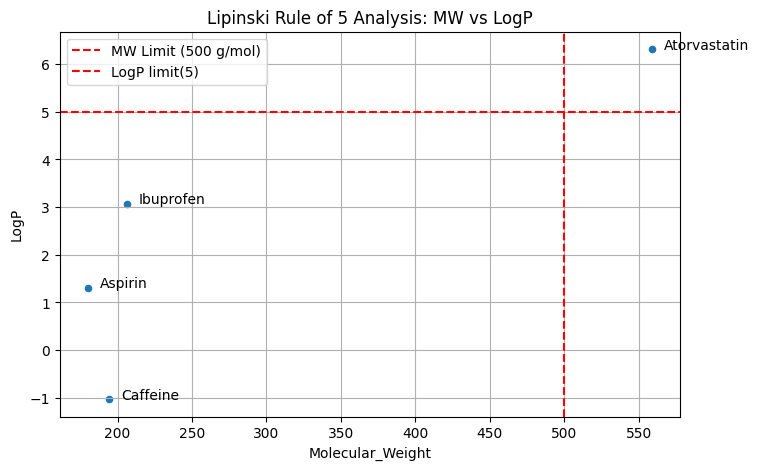

In [ ]:
#1. INSTALL & IMPORT LIBRARIES

!pip install rdkit
import pandas as pd
from rdkit import Chem
from rdkit.Chem import Descriptors
data = {
    "Drug_Name": ["Aspirin", "Ibuprofen", "Caffeine", "Atorvastatin"],
    "SMILES": [
        "CC(=O)OC1=CC=CC=C1C(=O)O",  # Aspirin
        "CC(C)CC1=CC=C(C=C1)C(C)C(=O)O",  # Ibuprofen
        "CN1C=NC2=C1C(=O)N(C(=O)N2C)C",  # Caffeine
        "CC(C)C1=C(C(=C(N1CCC(CC(CC(=O)O)O)O)C2=CC=C(C=C2)F)C3=CC=CC=C3)C(=O)NC4=CC=CC=C4",  # Atorvastatin
    ],
}
df=pd.DataFrame(data)
df["Mol"]=df["SMILES"].apply(Chem.MolFromSmiles)

#2. Define function to calculate physical descriptors

def calc_descriptors(molecule):
  return pd.Series({"Molecular_Weight":Descriptors.MolWt(molecule), "LogP":Descriptors.MolLogP(molecule),"HBA":Descriptors.NumHAcceptors(molecule),"HBD":Descriptors.NumHDonors(molecule)})

#3. Apply descriptor calculations

descriptors_df=df["Mol"].apply(calc_descriptors)
df=pd.concat([df,descriptors_df],axis=1)


# 3. Automate Lipinsk's rule check

def check_lipinski(row):
  violations=0
  if row["Molecular_Weight"]>500:
    violations+=1
  if row["LogP"]>5:
    violations+=1
  if row["HBA"]>10:
    violations+=1
  if row["HBD"]>5:
    violations+=1
  return "Pass" if violations<=1 else "Fail"
df["Lipinski_status"]=df.apply(check_lipinski, axis=1)
print(df[["Drug_Name","Molecular_Weight","LogP","HBA","HBD","Lipinski_status"]])

# 4. Visulaize results with panadas plots

ax=df.plot(kind="scatter",x="Molecular_Weight",y="LogP",title="Lipinski Rule of 5 Analysis: MW vs LogP",grid=True,figsize=(8,5))

# Add Lipinski threshold boundary lines
ax.axvline(x=500,color="red",linestyle="--", label= "MW Limit (500 g/mol)")
ax.axhline(y=5,color="red",linestyle="--",label="LogP limit(5)")

# Annotate drug names next to data points
for i in range(len(df)):
  ax.annotate(df["Drug_Name"][i],(df["Molecular_Weight"][i]+8,df["LogP"][i]),fontsize=10)
ax.legend()




